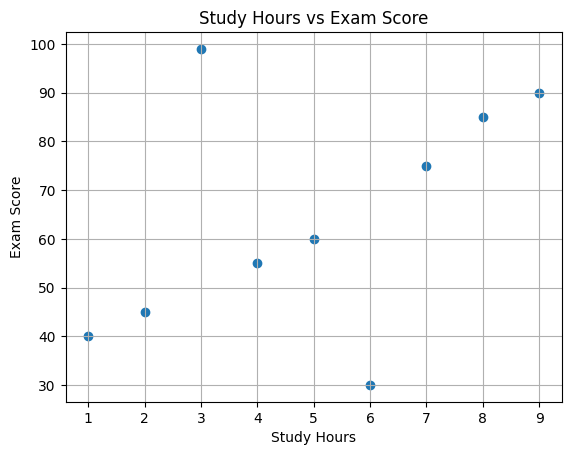

In [1]:
import matplotlib.pyplot as plt

# Sample data
study_hours = [1, 2, 3, 4, 5, 6, 7, 8, 9]
exam_scores = [40, 45, 99, 55, 60, 30, 75, 85, 90]

plt.scatter(study_hours, exam_scores)
plt.title('Study Hours vs Exam Score')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.grid(True)
plt.show()

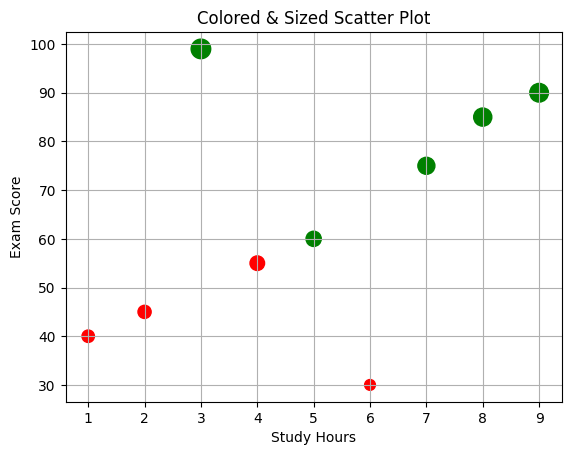

In [2]:
# Size of points based on score (bigger score -> bigger point)
sizes = [score * 2 for score in exam_scores]
colors = ['red' if score < 60 else 'green' for score in exam_scores]

plt.scatter(study_hours, exam_scores, s=sizes, c=colors)
plt.title('Colored & Sized Scatter Plot')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.grid(True)
plt.show()

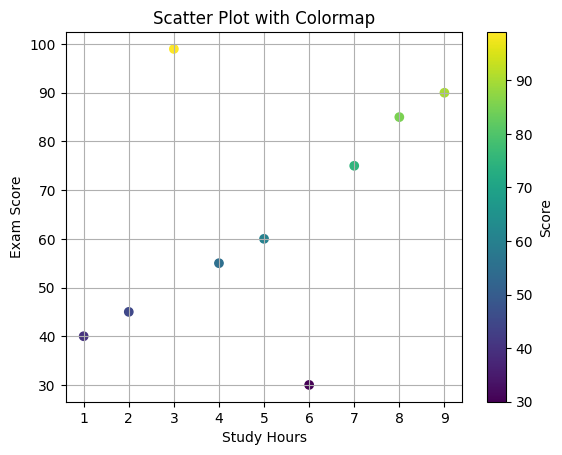

In [3]:
import numpy as np

# Also works with Numpy Arrays
scores_normalized = np.array(exam_scores)

plt.scatter(study_hours, exam_scores, c=scores_normalized, cmap='viridis')
plt.colorbar(label='Score')
plt.title('Scatter Plot with Colormap')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.grid(True)
plt.show()

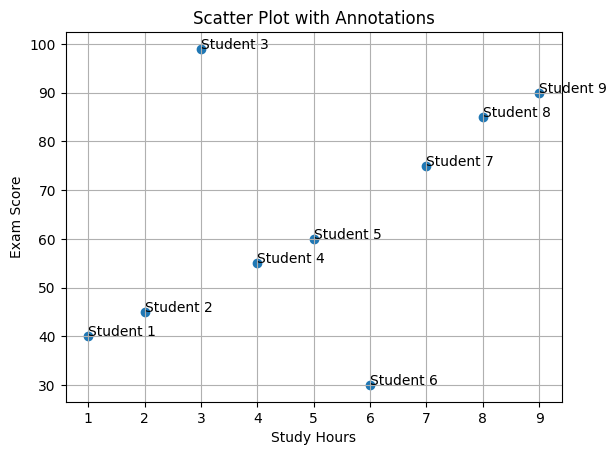

In [4]:
plt.scatter(study_hours, exam_scores)

# Add labels
for i in range(len(study_hours)):
    plt.annotate(f'Student {i+1}', (study_hours[i], exam_scores[i]))

plt.title('Scatter Plot with Annotations')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.grid(True)
plt.show()

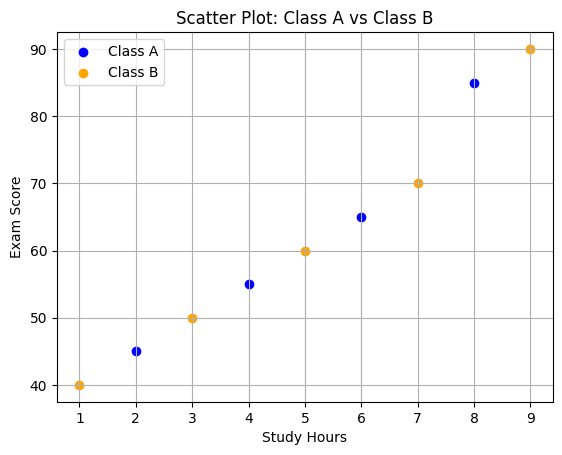

In [5]:
# Assume two groups: Class A and Class B
class_a_hours = [2, 4, 6, 8]
class_a_scores = [45, 55, 65, 85]

class_b_hours = [1, 3, 5, 7, 9]
class_b_scores = [40, 50, 60, 70, 90]

plt.scatter(class_a_hours, class_a_scores, label='Class A', color='blue')
plt.scatter(class_b_hours, class_b_scores, label='Class B', color='orange')

plt.title('Scatter Plot: Class A vs Class B')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
import matplotlib.pyplot as mpl
import numpy as np


mpl.rcParams.update({'font.size': 14})

# Indices to step through colormap.
x = np.linspace(0.0, 1.0, 100)

gradient = np.linspace(0, 1, 256)
gradient = np.vstack((gradient, gradient))


def plot_color_gradients(cmap_category, cmap_list):
    fig, axs = plt.subplots(nrows=len(cmap_list), ncols=2)
    fig.subplots_adjust(top=0.95, bottom=0.01, left=0.2, right=0.99,
                        wspace=0.05)
    fig.suptitle(cmap_category + ' colormaps', fontsize=14, y=1.0, x=0.6)

    for ax, name in zip(axs, cmap_list):

        # Get RGB values for colormap.
        rgb = mpl.colormaps[name](x)[np.newaxis, :, :3]

        # Get colormap in CAM02-UCS colorspace. We want the lightness.
        lab = cspace_converter("sRGB1", "CAM02-UCS")(rgb)
        L = lab[0, :, 0]
        L = np.float32(np.vstack((L, L, L)))

        ax[0].imshow(gradient, aspect='auto', cmap=mpl.colormaps[name])
        ax[1].imshow(L, aspect='auto', cmap='binary_r', vmin=0., vmax=100.)
        pos = list(ax[0].get_position().bounds)
        x_text = pos[0] - 0.01
        y_text = pos[1] + pos[3]/2.
        fig.text(x_text, y_text, name, va='center', ha='right', fontsize=10)

    # Turn off *all* ticks & spines, not just the ones with colormaps.
    for ax in axs.flat:
        ax.set_axis_off()

    plt.show()


for cmap_category, cmap_list in cmaps.items():

    plot_color_gradients(cmap_category, cmap_list)

NameError: name 'cmaps' is not defined